In [22]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [47]:
from sklearn import set_config
set_config(display="diagram")

Dataset: https://www.kaggle.com/datasets/amar5693/fake-and-real-news-dataset-4k

In [4]:
path = r"C:\Users\Rudra\Desktop\kaggle\fake-real\fake_news_dataset_4000_rows.csv"

In [5]:
df = pd.read_csv(path)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            4000 non-null   int64         
 1   title         4000 non-null   object        
 2   text          4000 non-null   object        
 3   author        4000 non-null   object        
 4   source        4000 non-null   object        
 5   topic         4000 non-null   object        
 6   publish_date  4000 non-null   datetime64[ns]
 7   year          4000 non-null   int64         
 8   month         4000 non-null   int64         
 9   day           4000 non-null   int64         
 10  word_count    4000 non-null   int64         
 11  char_count    4000 non-null   int64         
 12  title_length  4000 non-null   int64         
 13  label         4000 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(5)
memory usage: 437.6+ KB


In [11]:
df.sample(3)

,id,title,text,author,source,topic,publish_date,year,month,day,word_count,char_count,title_length,label
2596,2597,Celebrity Gossip Update 2597,This article discusses Celebrity Gossip Update...,Guest Writer,TruthExpose,Celebrity Gossip,2024-03-16,2024,3,16,32,226,28,0
2195,2196,Technology Update 2196,This article discusses Technology Update 2196....,Fatima Noor,The Guardian,Technology,2024-06-20,2024,6,20,29,213,22,1
2901,2902,Rumors Update 2902,This article discusses Rumors Update 2902. How...,Guest Writer,ClickDaily,Rumors,2023-04-03,2023,4,3,31,216,18,0


In [13]:
df["publish_date"] = pd.to_datetime(df["publish_date"])

In [37]:
for col in df.columns:
    print(f"{col} -> {df[col].nunique()}")

id -> 4000
title -> 4000
text -> 4000
author -> 12
source -> 12
topic -> 12
publish_date -> 727
year -> 2
month -> 12
day -> 31
word_count -> 3
char_count -> 20
title_length -> 13
label -> 2


# Word Cloud

In [24]:
text = " ".join(df["text"])
np.unique(text)

array(['This article discusses Miracle Cure Update 1. However, the claims are not supported by verified sources and may contain misleading or false information. Further details are provided with background context and analysis. This article discusses Conspiracy Update 2. However, the claims are not supported by verified sources and may contain misleading or false information. Further details are provided with background context and analysis. This article discusses Technology Update 3. The information has been verified by multiple trusted sources and supported by official statements. Further details are provided with background context and analysis. This article discusses Economy Update 4. The information has been verified by multiple trusted sources and supported by official statements. Further details are provided with background context and analysis. This article discusses Conspiracy Update 5. However, the claims are not supported by verified sources and may contain misleading or fal

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    colormap="viridis",
    max_words=300,
    include_numbers=True
).generate(text)

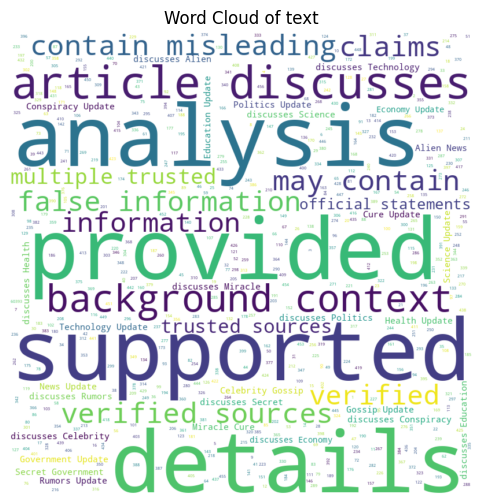

In [34]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Word Cloud of text")
plt.axis("off")
plt.show()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            4000 non-null   int64         
 1   title         4000 non-null   object        
 2   text          4000 non-null   object        
 3   author        4000 non-null   object        
 4   source        4000 non-null   object        
 5   topic         4000 non-null   object        
 6   publish_date  4000 non-null   datetime64[ns]
 7   year          4000 non-null   int64         
 8   month         4000 non-null   int64         
 9   day           4000 non-null   int64         
 10  word_count    4000 non-null   int64         
 11  char_count    4000 non-null   int64         
 12  title_length  4000 non-null   int64         
 13  label         4000 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(5)
memory usage: 437.6+ KB


In [48]:
df.columns

Index(['id', 'title', 'text', 'author', 'source', 'topic', 'publish_date',
       'year', 'month', 'day', 'word_count', 'char_count', 'title_length',
       'label'],
      dtype='object')

In [50]:
df = df.drop(columns=['id', 'year', 'month', 'day'])

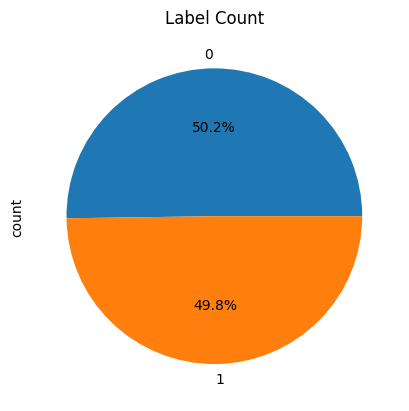

In [46]:
df["label"].value_counts().plot.pie(autopct="%2.1f%%", title="Label Count")
plt.show()

# Logistic Regression

In [67]:
X = df["text"]
y = df["label"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [71]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(3200,) (800,)
(3200,) (800,)


In [72]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10_000
)

tfidf

TfidfVectorizer(max_features=10000, stop_words='english')

In [73]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [74]:
print(X_train_tfidf.shape, X_test_tfidf.shape)

(3200, 3229) (800, 3229)


In [75]:
lg_model = LogisticRegression(max_iter=1_000)

In [76]:
lg_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [78]:
lg_y_pred = lg_model.predict(X_test_tfidf)

In [79]:
print(f"Accuracy {accuracy_score(y_test, lg_y_pred)}")
print(classification_report(y_test, lg_y_pred))

Accuracy 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       402
           1       1.00      1.00      1.00       398

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



- Very dangerous model 
- Accuracy is 1 
- 😆

# Adv Pipeline

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         4000 non-null   object        
 1   text          4000 non-null   object        
 2   author        4000 non-null   object        
 3   source        4000 non-null   object        
 4   topic         4000 non-null   object        
 5   publish_date  4000 non-null   datetime64[ns]
 6   word_count    4000 non-null   int64         
 7   char_count    4000 non-null   int64         
 8   title_length  4000 non-null   int64         
 9   label         4000 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 312.6+ KB


- 0 to 4: object 
- 6 to 9 are the int
- Means two pipeline for each 
- Then connect to the model

In [82]:
df.columns

Index(['title', 'text', 'author', 'source', 'topic', 'publish_date',
       'word_count', 'char_count', 'title_length', 'label'],
      dtype='object')

In [103]:
df["combined_text"] = (
    df["title"] + " " +
    df["text"] + " " +
    df["author"] + " " +
    df["source"] + " " +
    df["topic"] 
)

df["combined_text"]

0       Miracle Cure Update 1 This article discusses M...
1       Conspiracy Update 2 This article discusses Con...
2       Technology Update 3 This article discusses Tec...
3       Economy Update 4 This article discusses Econom...
4       Conspiracy Update 5 This article discusses Con...
                              ...                        
3995    Alien News Update 3996 This article discusses ...
3996    Technology Update 3997 This article discusses ...
3997    Politics Update 3998 This article discusses Po...
3998    Alien News Update 3999 This article discusses ...
3999    Celebrity Gossip Update 4000 This article disc...
Name: combined_text, Length: 4000, dtype: object

In [105]:
text_features = "combined_text" 
num_features = ['word_count', 'char_count', 'title_length']

In [106]:
tfidf = TfidfVectorizer(stop_words="english", max_features=10_000)
sds = StandardScaler()

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", tfidf , text_features),
        ("num", sds, num_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('text',
                                 TfidfVectorizer(max_features=10000,
                                                 stop_words='english'),
                                 'combined_text'),
                                ('num', StandardScaler(),
                                 ['word_count', 'char_count', 'title_length'])])

In [108]:
log_model = LogisticRegression(max_iter=1_000)
log_model

LogisticRegression(max_iter=1000)

In [109]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", log_model)
])

pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  stop_words='english'),
                                                  'combined_text'),
                                                 ('num', StandardScaler(),
                                                  ['word_count', 'char_count',
                                                   'title_length'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [110]:
df.columns

Index(['title', 'text', 'author', 'source', 'topic', 'publish_date',
       'word_count', 'char_count', 'title_length', 'label', 'combined_text'],
      dtype='object')

In [111]:
X = df.drop(columns=["publish_date", "label"])
y = df["label"]

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [113]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(3200, 9) (800, 9)
(3200,) (800,)


In [114]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  stop_words='english'),
                                                  'combined_text'),
                                                 ('num', StandardScaler(),
                                                  ['word_count', 'char_count',
                                                   'title_length'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [116]:
y_pred_pipeline =  pipeline.predict(X_test)

In [117]:
print(f"Accuracy {accuracy_score(y_test, y_pred_pipeline)}")
print(classification_report(y_test, y_pred_pipeline))

Accuracy 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       402
           1       1.00      1.00      1.00       398

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

